In [56]:
import re
import numpy as np
import pandas as pd

from sklearn.metrics import confusion_matrix

from analysis_shared_functions import bulk_vs_singlecell_matrix_viz, all_samples_matrix_viz

In [ ]:
DATA_PATH = "../../data/output_data/"
FIGURES_PATH = "../../data/figures/"
tool = "NGSCheckmate"
dataset = "low_grade_glioma"
pseudobulk = True
ncells = 100000
rd = 1

# Data munging

## Similarity matrix

In [5]:
if pseudobulk:  
    ngscheckmate_df = pd.read_csv(
        DATA_PATH + 
        f"2a_ngscheckmate/{dataset}/pseudobulk/ncells_{ncells}/read_depth_{rd}/output_all.txt", 
        sep="\t", index_col=0, header=None
    )
else:
    ngscheckmate_df = pd.read_csv(
        DATA_PATH + 
        f"2a_ngscheckmate/{dataset}/real_data/ncells_{ncells}/read_depth_{rd}/output_all.txt", 
        sep="\t", index_col=0, header=None
    )

In [7]:
if dataset == "hgsoc":
    regex_exp = r"[a-zA-Z0-9]{32}_"
elif dataset == "low_grade_glioma":
    regex_exp = r"^GSM[0-9]{7}_"

ngscheckmate_dict = {
    x: 
    re.sub(regex_exp, "", x.replace(".vcf", "").replace("ds.", "").replace("_individual_variants", ""))
    for x in list(set(ngscheckmate_df.index) | set(ngscheckmate_df[2]))
}
ngscheckmate_df.index = ngscheckmate_df.index.map(ngscheckmate_dict)
ngscheckmate_df[2] = ngscheckmate_df[2].map(ngscheckmate_dict)
ngscheckmate_df.columns = ["Matched", "Sample", "Binary", "Correlation"]

In [8]:
ngscheckmate_df.head()

,Matched,Sample,Binary,Correlation
0,,,,
pseudobulk_GSM7326880_ncells_100000_1,matched,pseudobulk_GSM7326880_ncells_100000_2,1.0000,0.0
pseudobulk_GSM7326880_ncells_100000_1,matched,pseudobulk_GSM7326880_ncells_100000_3,1.0000,0.0
pseudobulk_GSM7326880_ncells_100000_1,unmatched,pseudobulk_GSM7326881_ncells_100000_1,0.1674,0.0
pseudobulk_GSM7326880_ncells_100000_1,unmatched,pseudobulk_GSM7326881_ncells_100000_2,0.1674,0.0
pseudobulk_GSM7326880_ncells_100000_1,unmatched,pseudobulk_GSM7326881_ncells_100000_3,0.1674,0.0


In [42]:
def long_df_to_matrix_ngscheckmate(df, metric="Correlation"):
    # Use pivot_table for much faster matrix creation
    matrix = df.pivot_table(
        index=0,
        columns='Sample',
        values=metric,
        aggfunc='first'  # Use first value if duplicates exist
    )
    
    # Convert correlation values to percentage (divide by 100)
    if metric == "Correlation":
        matrix = matrix / 100
    
    # Get all unique samples to create a square matrix
    all_samples = sorted(set(df.index) | set(df['Sample']))
    matrix = matrix.reindex(index=all_samples, columns=all_samples)
    
    # Make matrix symmetric by filling NaN values
    matrix = matrix.combine_first(matrix.T)
    
    # Order rows and columns by bulk modality and sample ID
    matrix = matrix.sort_index(
        key=lambda x: x.str.split('_').str[0]).sort_index(key=lambda x: x.str.split('_', n=1).str[1]
    )
    matrix = matrix.reindex(
        sorted(
            sorted(
                matrix.columns,
                key=lambda x: x.split('_', 1)[0]
            ),
            key=lambda x: x.split('_', 1)[1]
        )
    )
    matrix = matrix[matrix.index]

    return matrix

In [11]:
ngscheckmate_matrix = long_df_to_matrix_ngscheckmate(ngscheckmate_df)

In [13]:
ngscheckmate_matrix.head()

,pseudobulk_GSM7326880_ncells_100000_1,pseudobulk_GSM7326880_ncells_100000_2,pseudobulk_GSM7326880_ncells_100000_3,pseudobulk_GSM7326881_ncells_100000_1,pseudobulk_GSM7326881_ncells_100000_2,pseudobulk_GSM7326881_ncells_100000_3,pseudobulk_GSM7326883_ncells_100000_1,pseudobulk_GSM7326883_ncells_100000_2,pseudobulk_GSM7326883_ncells_100000_3,pseudobulk_GSM7326884_ncells_100000_1,...,pseudobulk_GSM7326901_ncells_100000_3,pseudobulk_GSM7326902_ncells_100000_1,pseudobulk_GSM7326902_ncells_100000_2,pseudobulk_GSM7326902_ncells_100000_3,pseudobulk_GSM7326903_ncells_100000_1,pseudobulk_GSM7326903_ncells_100000_2,pseudobulk_GSM7326903_ncells_100000_3,pseudobulk_GSM7326905_ncells_100000_1,pseudobulk_GSM7326905_ncells_100000_2,pseudobulk_GSM7326905_ncells_100000_3
0,,,,,,,,,,,,,,,,,,,,,
pseudobulk_GSM7326880_ncells_100000_1,NaN,0.0,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0,0.0,0.0,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
pseudobulk_GSM7326880_ncells_100000_2,0.0,NaN,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0,0.0,0.0,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
pseudobulk_GSM7326880_ncells_100000_3,0.0,0.0,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0,0.0,0.0,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
pseudobulk_GSM7326881_ncells_100000_1,0.0,0.0,0.0,NaN,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001,...,0.0,0.0,0.0,0.0,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001
pseudobulk_GSM7326881_ncells_100000_2,0.0,0.0,0.0,0.0001,NaN,0.0001,0.0001,0.0001,0.0001,0.0001,...,0.0,0.0,0.0,0.0,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001


In [14]:
ngscheckmate_matrix.shape

(66, 66)

## Sample matches

In [69]:
inferred_matches = long_df_to_matrix_ngscheckmate(ngscheckmate_df, "Matched").replace("unmatched", 0).replace("matched", 1)

/var/folders/yj/bt5772fx4p1cg9s9jbwzf0r00000gp/T/ipykernel_22138/2659389756.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  inferred_matches = long_df_to_matrix_ngscheckmate(ngscheckmate_df, "Matched").replace("unmatched", 0).replace("matched", 1)


In [70]:
inferred_matches.head()

,pseudobulk_GSM7326880_ncells_100000_1,pseudobulk_GSM7326880_ncells_100000_2,pseudobulk_GSM7326880_ncells_100000_3,pseudobulk_GSM7326881_ncells_100000_1,pseudobulk_GSM7326881_ncells_100000_2,pseudobulk_GSM7326881_ncells_100000_3,pseudobulk_GSM7326883_ncells_100000_1,pseudobulk_GSM7326883_ncells_100000_2,pseudobulk_GSM7326883_ncells_100000_3,pseudobulk_GSM7326884_ncells_100000_1,...,pseudobulk_GSM7326901_ncells_100000_3,pseudobulk_GSM7326902_ncells_100000_1,pseudobulk_GSM7326902_ncells_100000_2,pseudobulk_GSM7326902_ncells_100000_3,pseudobulk_GSM7326903_ncells_100000_1,pseudobulk_GSM7326903_ncells_100000_2,pseudobulk_GSM7326903_ncells_100000_3,pseudobulk_GSM7326905_ncells_100000_1,pseudobulk_GSM7326905_ncells_100000_2,pseudobulk_GSM7326905_ncells_100000_3
0,,,,,,,,,,,,,,,,,,,,,
pseudobulk_GSM7326880_ncells_100000_1,NaN,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
pseudobulk_GSM7326880_ncells_100000_2,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
pseudobulk_GSM7326880_ncells_100000_3,1.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
pseudobulk_GSM7326881_ncells_100000_1,0.0,0.0,0.0,NaN,1.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
pseudobulk_GSM7326881_ncells_100000_2,0.0,0.0,0.0,1.0,NaN,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [71]:
# Check that the index and columns are ordered the same way
all(inferred_matches.index == inferred_matches.columns)

True

# Real data viz & analysis

In [ ]:
bulk_vs_singlecell_matrix_viz(
    ngscheckmate_matrix,
    pseudobulk=pseudobulk,
    tool=tool,
    dataset=dataset,
    ncells=ncells,
    rd=rd,
    save_fig=False
)

## Comparison with expected matches

# Pseudobulk viz & analysis

In [21]:
# Filter NGSCheckmate matrix to only samples ending in _1 in rows and samples ending in _2 in columns (or _2 vs _3 or _1 vs _3)
pseudobulk_1 = "_1"
pseudobulk_2 = "_2"
pseudobulk_regex = r"_[1-3]{1}$"
ngscheckmate_matrix_filtered = ngscheckmate_matrix.loc[
    [idx for idx in ngscheckmate_matrix.index if idx.endswith(pseudobulk_1)],
    [col for col in ngscheckmate_matrix.columns if col.endswith(pseudobulk_2)]
]

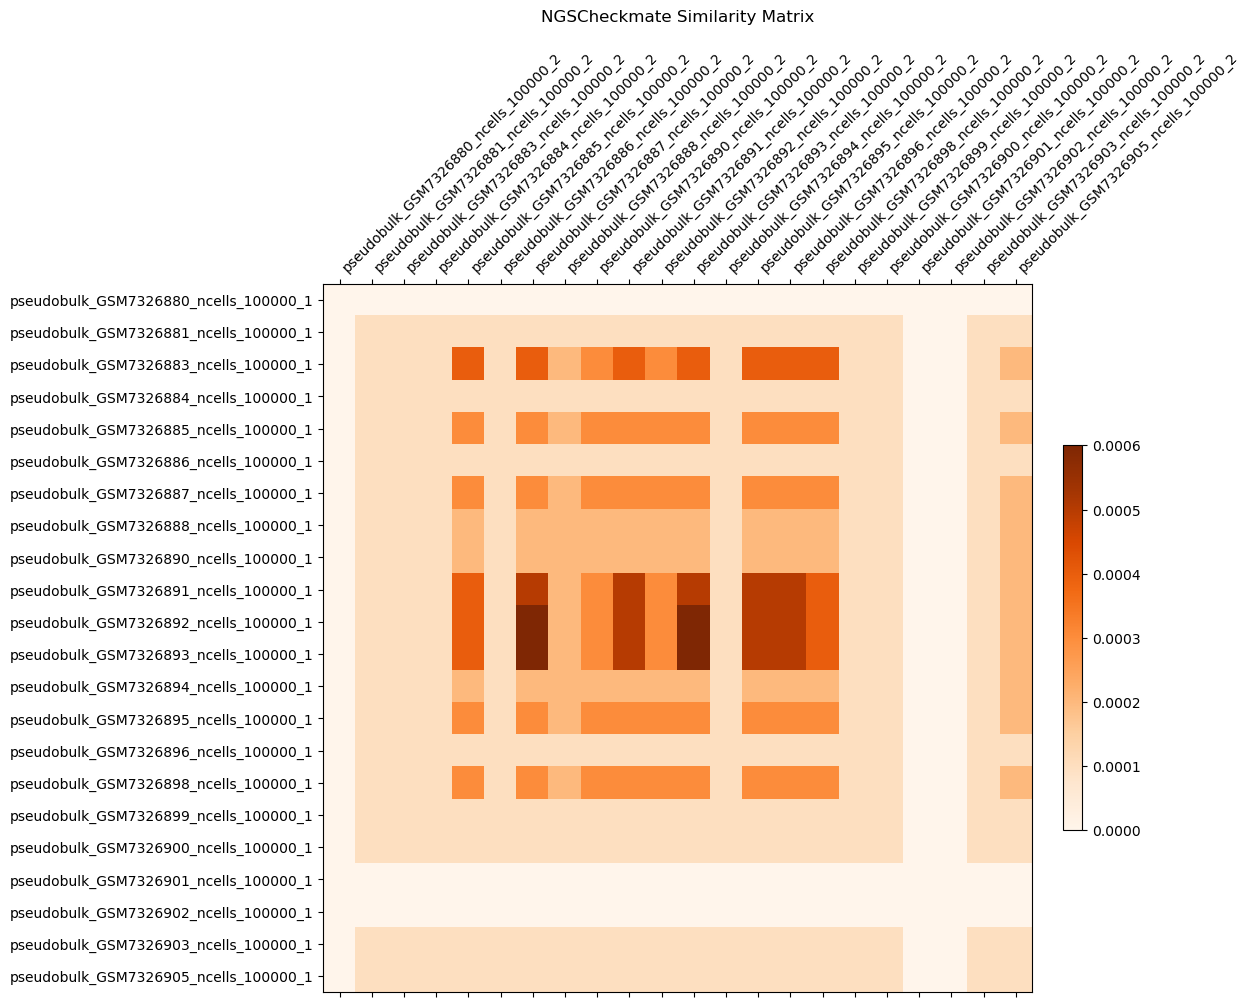

In [22]:
all_samples_matrix_viz(
    ngscheckmate_matrix_filtered, 
    pseudobulk=pseudobulk, 
    tool=tool, 
    dataset=dataset, 
    ncells=ncells, 
    rd=rd, 
    save_fig=False
)

## Detailed accuracy metrics

In [82]:
# Create inferred_matches matrix for submatrix 
inferred_matches_submatrix = inferred_matches.loc[
    [idx for idx in inferred_matches.index if idx.endswith(pseudobulk_1)],
    [col for col in inferred_matches.columns if col.endswith(pseudobulk_2)]
]

In [84]:
inferred_matches_submatrix.head()

,pseudobulk_GSM7326880_ncells_100000_2,pseudobulk_GSM7326881_ncells_100000_2,pseudobulk_GSM7326883_ncells_100000_2,pseudobulk_GSM7326884_ncells_100000_2,pseudobulk_GSM7326885_ncells_100000_2,pseudobulk_GSM7326886_ncells_100000_2,pseudobulk_GSM7326887_ncells_100000_2,pseudobulk_GSM7326888_ncells_100000_2,pseudobulk_GSM7326890_ncells_100000_2,pseudobulk_GSM7326891_ncells_100000_2,...,pseudobulk_GSM7326894_ncells_100000_2,pseudobulk_GSM7326895_ncells_100000_2,pseudobulk_GSM7326896_ncells_100000_2,pseudobulk_GSM7326898_ncells_100000_2,pseudobulk_GSM7326899_ncells_100000_2,pseudobulk_GSM7326900_ncells_100000_2,pseudobulk_GSM7326901_ncells_100000_2,pseudobulk_GSM7326902_ncells_100000_2,pseudobulk_GSM7326903_ncells_100000_2,pseudobulk_GSM7326905_ncells_100000_2
0,,,,,,,,,,,,,,,,,,,,,
pseudobulk_GSM7326880_ncells_100000_1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
pseudobulk_GSM7326881_ncells_100000_1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
pseudobulk_GSM7326883_ncells_100000_1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
pseudobulk_GSM7326884_ncells_100000_1,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
pseudobulk_GSM7326885_ncells_100000_1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [91]:
# Create true_matches matrix for submatrix 
# Matches on the diagonal (1), the rest non-matches (0)
true_matches = pd.DataFrame(
    np.identity(len(inferred_matches_submatrix)),
    index=pd.Index(inferred_matches_submatrix.index, name="pseudobulk_1"), 
    columns=pd.Index(inferred_matches_submatrix.columns, name="pseudobulk_2"),
    )

In [ ]:
# Melt matrices into long form 
true_matches_long = true_matches.stack().rename("match").reset_index().set_index(["pseudobulk_1", "pseudobulk_2"])
inferred_matches_long = inferred_matches_submatrix.stack().rename("match").reset_index().set_index([0, "level_1"])

In [ ]:
# Calculate confusion matrix
tn, fp, fn, tp = confusion_matrix(true_matches_long, inferred_matches_long).ravel().tolist()

In [128]:
accuracy = (tp + tn) / (tp + tn + fp + fn)
tpr = tp / (tp + fn)
tnr = tn / (tn + fp)
balanced_accuracy = (tpr + tnr) / 2
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * precision * recall / (precision + recall)

print(f"Accuracy = {accuracy:.2f}")
print(f"Balanced accuracy = {balanced_accuracy:.2f}")
print(f"Precision = {precision:.2f}")
print(f"Recall = {recall:.2f}")
print(f"F1 = {f1:.2f}")

Accuracy = 0.84
Balanced accuracy = 0.85
Precision = 0.20
Recall = 0.86
F1 = 0.32
